In [1]:
import warnings
import torch

from dataset import OptionsDataModule
from model import OptionNetModule
import lightning as pl
warnings.filterwarnings("ignore")

In [2]:
lr = 6e-4
EPOCHS = 60
batch_size = 256
LAMBDA_ARB = 100.0

torch.manual_seed(42)

In [3]:
from lightning.pytorch.callbacks import LearningRateMonitor
from lightning.pytorch.loggers import TensorBoardLogger

data_module = OptionsDataModule("./data/108105", sofr_path="./data/sofr.csv", batch_size=batch_size)
lr_monitor = LearningRateMonitor(logging_interval='epoch')

model = OptionNetModule(
    n_inputs=9,
    n_hidden=50,
    n_layers=2,
    lambda_arb=LAMBDA_ARB,
    learning_rate=lr,
)

trainer = pl.Trainer(
    max_epochs=EPOCHS,
    accelerator="auto",
    devices=1,
    enable_progress_bar=True,
    log_every_n_steps=10,
    logger=TensorBoardLogger("./logs/", name="my_experiment", version="Baseline w sofr"),
    callbacks=[lr_monitor]
)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [4]:
trainer.fit(model, data_module)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Train: 357036 | Validation: 44629 | Test: 44630


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ OptionNet          │  3.1 K │ train │     0 │
│ 1 │ loss_fn │ GreeksInformedLoss │      0 │ train │     0 │
└───┴─────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 3.1 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 3.1 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 10                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_epochs=60` reached.


Scatterplot saved to predicted_vs_actual.png


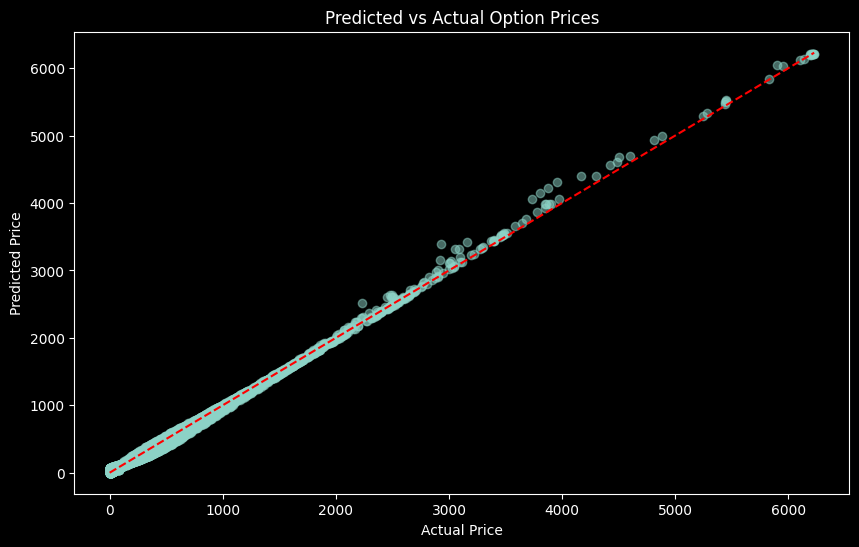

In [5]:
# Visualization
import matplotlib.pyplot as plt
import numpy as np

model.eval()
val_loader = data_module.test_dataloader()

all_preds = []
all_actuals = []


for idx, batch in enumerate(val_loader):
    x, y = batch
    preds, _ = model(x)
    all_preds.append(preds.detach().numpy() * x[:, 1].numpy().reshape(-1, 1))
    all_actuals.append(y.numpy() * x[:, 1].numpy().reshape(-1, 1))

all_preds = np.concatenate(all_preds).flatten()
all_actuals = np.concatenate(all_actuals).flatten()

plt.figure(figsize=(10, 6))
plt.scatter(all_actuals, all_preds, alpha=0.5)
plt.plot([all_actuals.min(), all_actuals.max()], [all_actuals.min(), all_actuals.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Predicted vs Actual Option Prices')
plt.savefig('predicted_vs_actual.png')
print("Scatterplot saved to predicted_vs_actual.png")

Scatterplot saved to predicted_vs_actual.png


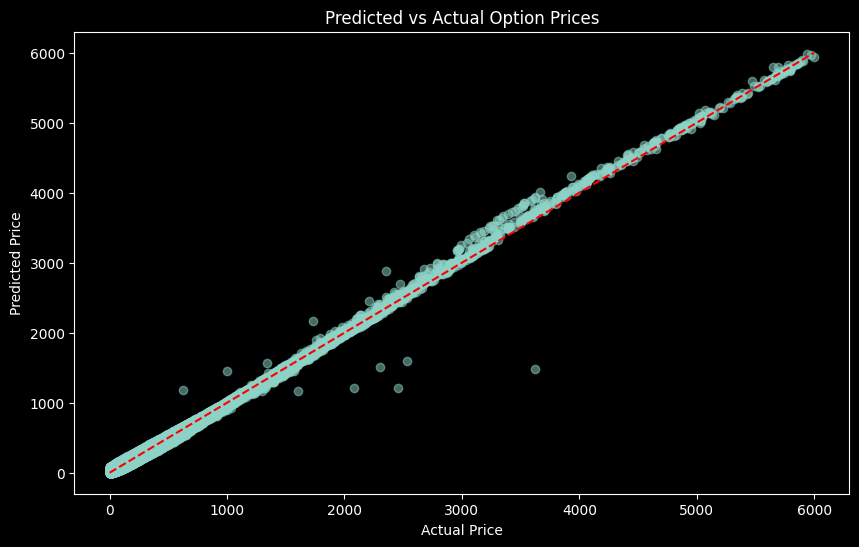

In [6]:
model.eval()
val_loader = data_module.train_dataloader()

all_preds = []
all_actuals = []


for batch in val_loader:
    x, y = batch
    preds, _ = model(x)
    all_preds.append(preds.detach().numpy() * x[:, 1].numpy().reshape(-1, 1))
    all_actuals.append(y.numpy() * x[:, 1].numpy().reshape(-1, 1))


all_preds = np.concatenate(all_preds).flatten()
all_actuals = np.concatenate(all_actuals).flatten()

plt.figure(figsize=(10, 6))
plt.scatter(all_actuals, all_preds, alpha=0.5)
plt.plot([all_actuals.min(), all_actuals.max()], [all_actuals.min(), all_actuals.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Predicted vs Actual Option Prices')
plt.savefig('predicted_vs_actual.png')
print("Scatterplot saved to predicted_vs_actual.png")